In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import itertools
import seaborn as sns

# Results in a single run

In [2]:
def plot(file_result, file_synapses, frequency1, frequency2, amplitude, ltp_start = 1000, ltp_end = 2000):
    result = pd.read_csv(file_result, index_col = 0)
    synapse_weights = pd.read_csv(file_synapses, index_col = 0)

    is_ti = frequency1 != frequency2
    
    fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3.5))
    
    axs[0].plot(result.Time, result.Soma, label = "Soma", lw = 0.5, color = "black")
    axs[0].set_ylabel(r"$V_m$, mV")
    axs[0].set_xlabel("Time, ms")
    axs[0].set_ylim(-110, 70)
    axs[0].axvspan(
        ltp_start, ltp_end, alpha = 0.1,
        color = "orange",
        label = "LTP induction",
    )
    
    if is_ti:
        axs[0].set_title(rf"TI $\Delta f = {abs(int(frequency1 - frequency2))}$ Hz" + "\n" + rf"$E_0 = {amplitude}$ V/m")
    else:
        axs[0].set_title(rf"$f = {int(frequency1)}$ Hz" + "\n" + rf"$E_0 = {amplitude}$ V/m")
    
    for column in synapse_weights:
        synapse = synapse_weights[column]
        axs[1].plot(result.Time, synapse / 0.0002, linewidth = 0.5)
    
    if is_ti:
        axs[1].set_title(rf"TI $\Delta f = {abs(int(frequency1 - frequency2))}$ Hz" + "\n" + rf"$E_0 = {amplitude}$ V/m")
    else:
        axs[1].set_title(rf"$f = {int(frequency1)}$ Hz" + "\n" + rf"$E_0 = {amplitude}$ V/m")
    
    axs[1].set_ylim(-0.1, 1.1)
    
    axs[1].axvspan(
        ltp_start, ltp_end, alpha = 0.1,
        color = "orange",
        label = "LTP induction",
    )
    
    axs[1].set_xlabel("Time, ms")
    axs[1].set_ylabel("Synaptic strength")
    
    plt.tight_layout()

In [3]:
i = 6

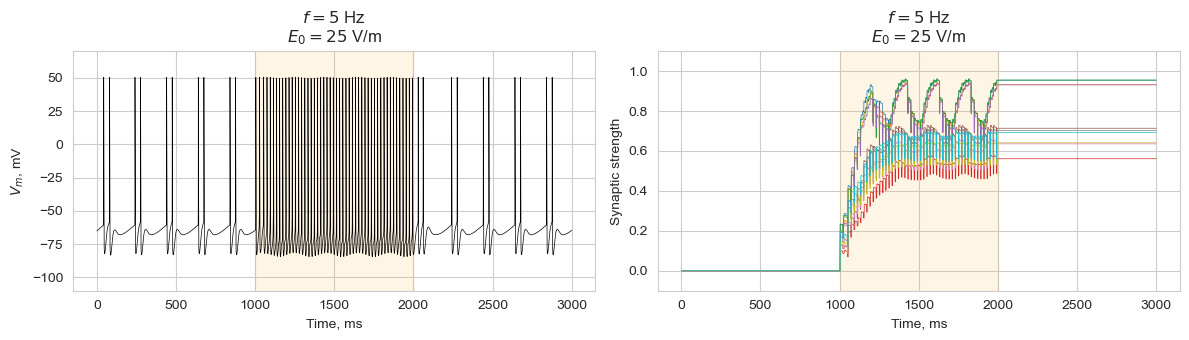

In [4]:
plot(
    f"output/ti/cns/simulation_{i}/simulation_5hz_vm.csv",
    f"output/ti/cns/simulation_{i}/simulation_5hz_synaptic_weights.csv",
    frequency1 = 5,
    frequency2 = 5,
    amplitude = 25
)

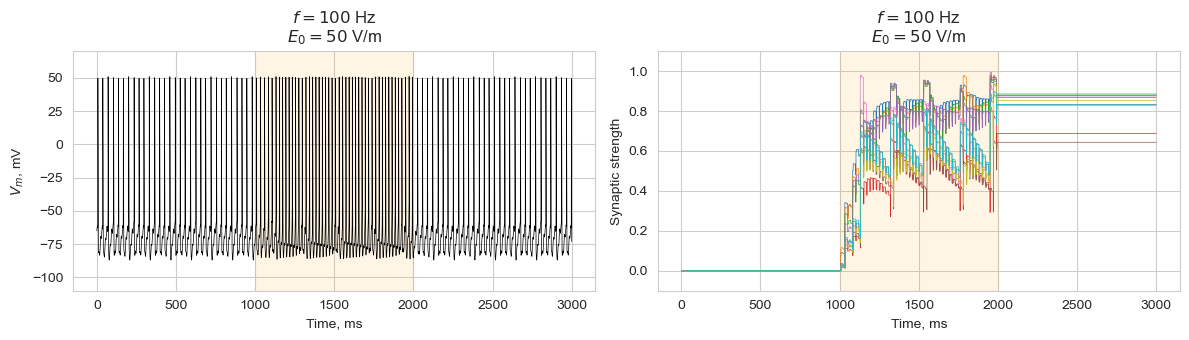

In [5]:
plot(
    f"output/ti/cns/simulation_{i}/simulation_100hz_vm.csv",
    f"output/ti/cns/simulation_{i}/simulation_100hz_synaptic_weights.csv",
    frequency1 = 100,
    frequency2 = 100,
    amplitude = 50
)

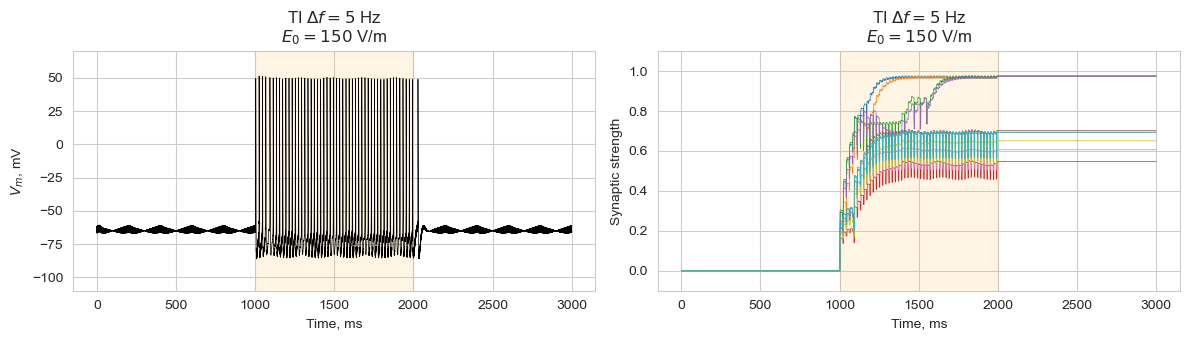

In [6]:
plot(
    f"output/ti/cns/simulation_{i}/simulation_ti_5hz_vm.csv",
    f"output/ti/cns/simulation_{i}/simulation_ti_5hz_synaptic_weights.csv",
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 150
)

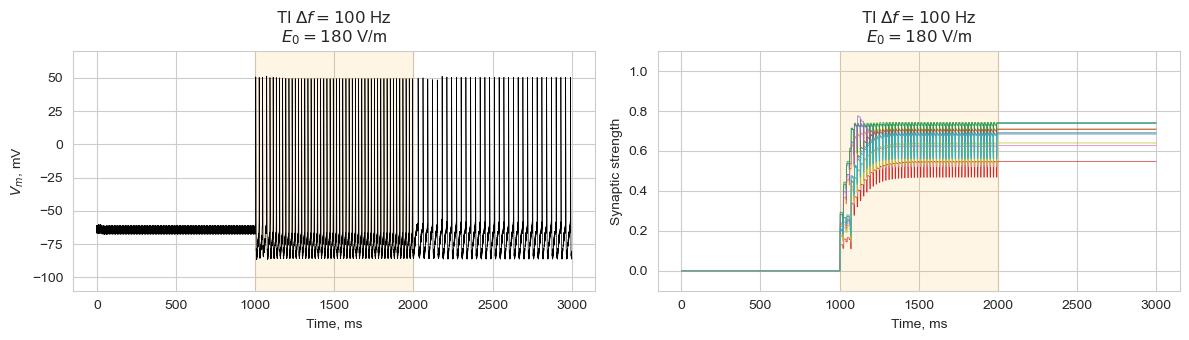

In [7]:
plot(
    f"output/ti/cns/simulation_{i}/simulation_ti_100hz_vm.csv",
    f"output/ti/cns/simulation_{i}/simulation_ti_100hz_synaptic_weights.csv",
    frequency1 = 1000,
    frequency2 = 1100,
    amplitude = 180
)

# Synapse weight distributions from multiple runs

In [8]:
def read_all_final_synaptic_weights(filetype):
    synaptic_weights = []
    for file in glob(f"output/ti/cns/simulation_*/simulation_{filetype}_synaptic_weights.csv"):
        run = pd.read_csv(file, index_col = 0)
        weights = np.array(run.iloc[-1]) / 0.0002
        synaptic_weights.append(weights.tolist())

    synaptic_weights = list(itertools.chain(*synaptic_weights))
    return synaptic_weights

In [13]:
synaptic_weights_none = read_all_final_synaptic_weights("none")

synaptic_weights_5hz = read_all_final_synaptic_weights("5hz")
synaptic_weights_ti_5hz = read_all_final_synaptic_weights("ti_5hz")

synaptic_weights_100Hz = read_all_final_synaptic_weights("100hz")
synaptic_weights_ti_100Hz = read_all_final_synaptic_weights("ti_100hz")

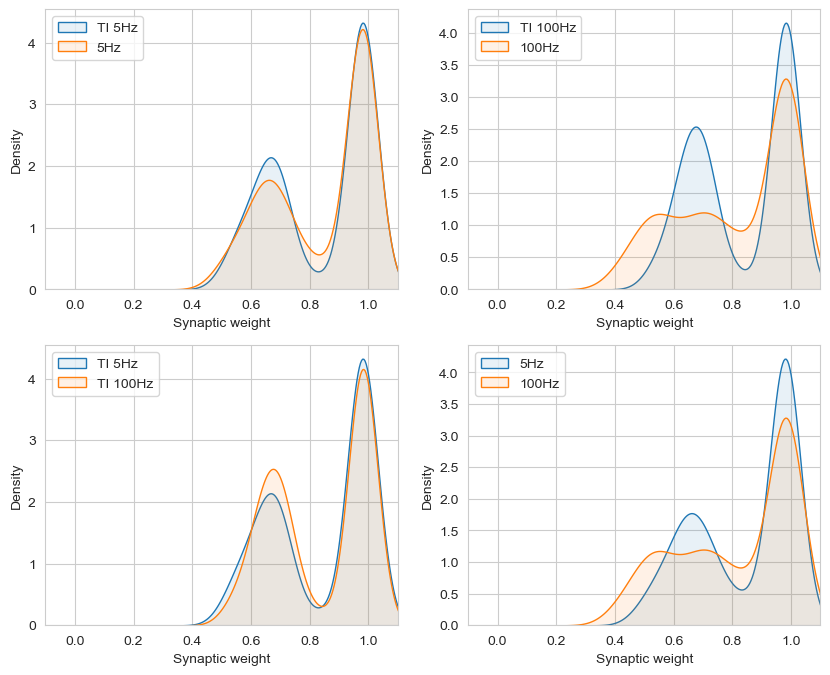

In [14]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))
axs = axs.flatten()

# sns.kdeplot(synaptic_weights_none, ax = axs[0], fill = True, alpha = 0.1, label = "None")
sns.kdeplot(synaptic_weights_ti_5hz, ax = axs[0], fill = True, alpha = 0.1, label = "TI 5Hz")
sns.kdeplot(synaptic_weights_5hz, ax = axs[0], fill = True, alpha = 0.1, label = "5Hz")

# sns.kdeplot(synaptic_weights_none, ax = axs[1], fill = True, alpha = 0.1, label = "None")
sns.kdeplot(synaptic_weights_ti_100Hz, ax = axs[1], fill = True, alpha = 0.1, label = "TI 100Hz")
sns.kdeplot(synaptic_weights_100Hz, ax = axs[1], fill = True, alpha = 0.1, label = "100Hz")

# sns.kdeplot(synaptic_weights_none, ax = axs[2], fill = True, alpha = 0.1, label = "None")
sns.kdeplot(synaptic_weights_ti_5hz, ax = axs[2], fill = True, alpha = 0.1, label = "TI 5Hz")
sns.kdeplot(synaptic_weights_ti_100Hz, ax = axs[2], fill = True, alpha = 0.1, label = "TI 100Hz")

# sns.kdeplot(synaptic_weights_none, ax = axs[3], fill = True, alpha = 0.1, label = "None")
sns.kdeplot(synaptic_weights_5hz, ax = axs[3], fill = True, alpha = 0.1, label = "5Hz")
sns.kdeplot(synaptic_weights_100Hz, ax = axs[3], fill = True, alpha = 0.1, label = "100Hz")

for ax in axs:
    ax.set_xlabel("Synaptic weight")
    ax.set_xlim(-0.1, 1.1)
    ax.legend(loc = "upper left")

plt.show()

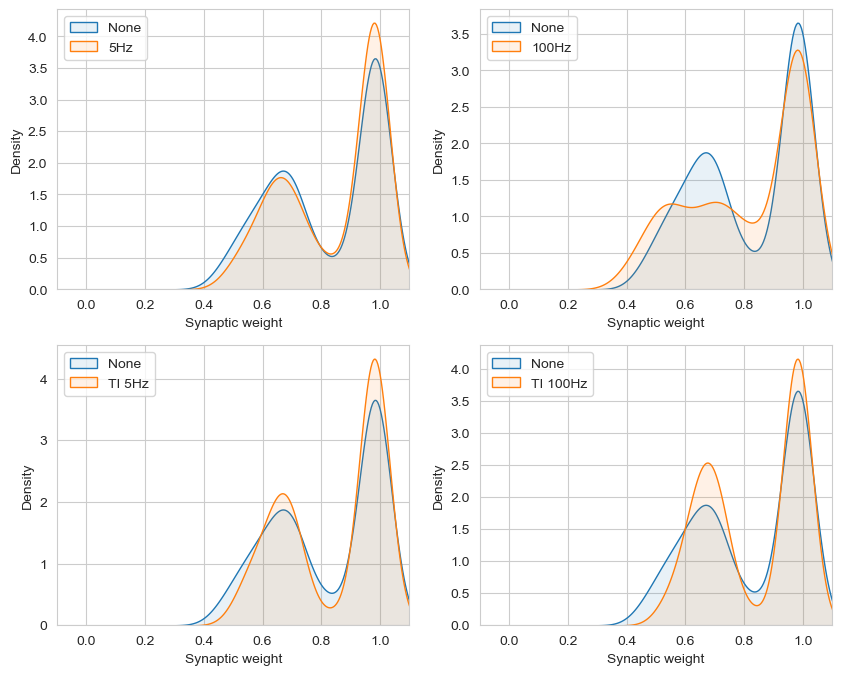

In [15]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))
axs = axs.flatten()

sns.kdeplot(synaptic_weights_none, ax = axs[0], fill = True, alpha = 0.1, label = "None")
# sns.kdeplot(synaptic_weights_ti_5hz, ax = axs[0], fill = True, alpha = 0.1, label = "TI 5Hz")
sns.kdeplot(synaptic_weights_5hz, ax = axs[0], fill = True, alpha = 0.1, label = "5Hz")

sns.kdeplot(synaptic_weights_none, ax = axs[1], fill = True, alpha = 0.1, label = "None")
# sns.kdeplot(synaptic_weights_ti_100Hz, ax = axs[1], fill = True, alpha = 0.1, label = "TI 100Hz")
sns.kdeplot(synaptic_weights_100Hz, ax = axs[1], fill = True, alpha = 0.1, label = "100Hz")

sns.kdeplot(synaptic_weights_none, ax = axs[2], fill = True, alpha = 0.1, label = "None")
sns.kdeplot(synaptic_weights_ti_5hz, ax = axs[2], fill = True, alpha = 0.1, label = "TI 5Hz")
# sns.kdeplot(synaptic_weights_ti_100Hz, ax = axs[2], fill = True, alpha = 0.1, label = "TI 100Hz")

sns.kdeplot(synaptic_weights_none, ax = axs[3], fill = True, alpha = 0.1, label = "None")
# sns.kdeplot(synaptic_weights_5hz, ax = axs[3], fill = True, alpha = 0.1, label = "5Hz")
sns.kdeplot(synaptic_weights_ti_100Hz, ax = axs[3], fill = True, alpha = 0.1, label = "TI 100Hz")
# sns.kdeplot(synaptic_weights_100Hz, ax = axs[3], fill = True, alpha = 0.1, label = "100Hz")

for ax in axs:
    ax.set_xlabel("Synaptic weight")
    ax.set_xlim(-0.1, 1.1)
    ax.legend(loc = "upper left")

plt.show()